In [11]:
import pandas as pd
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report



In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
df=pd.read_csv("test.csv")

In [16]:
df.columns = ["label","title","description"]

df["text"] = df["title"] + " " + df["description"]

df.head()

,label,title,description,text
0,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...
1,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...
2,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...
3,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...
4,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...,Open Letter Against British Copyright Indoctri...


In [17]:
df["text"] = df["text"].str.lower()

In [18]:
def clean(text):
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    text = re.sub(r'\s+',' ',text)
    return text.strip()

df["text"] = df["text"].apply(clean)

In [20]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop = set(stopwords.words("english"))

df["text"] = df["text"].apply(
    lambda x: " ".join([w for w in x.split() if w not in stop])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)

X = tfidf.fit_transform(df["text"])

y = df["label"]

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [27]:
pred = model.predict(X_test)

In [28]:
news = """
Apple launches its latest AI-powered iPhone with improved
battery life and advanced machine learning features.
"""

news = clean(news)

vec = tfidf.transform([news])

prediction = model.predict(vec)[0]

labels = {
    1:"World",
    2:"Sports",
    3:"Business",
    4:"Sci/Tech"
}

print(labels[prediction])

Sci/Tech


In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:",accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy: 0.8789473684210526
              precision    recall  f1-score   support

           1       0.90      0.90      0.90       380
           2       0.93      0.96      0.94       380
           3       0.86      0.79      0.82       380
           4       0.83      0.87      0.85       380

    accuracy                           0.88      1520
   macro avg       0.88      0.88      0.88      1520
weighted avg       0.88      0.88      0.88      1520



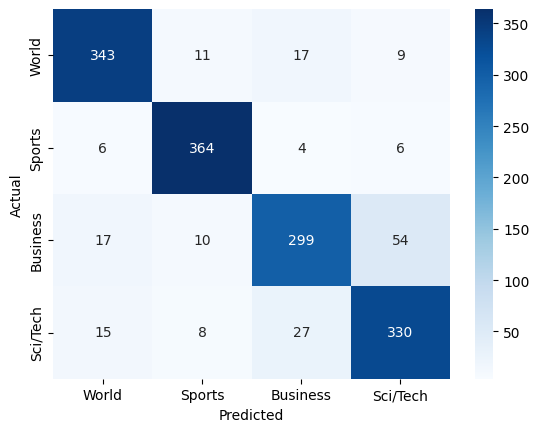

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels.values(),
    yticklabels=labels.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()